# Exploring NMF and PCA on Handwritten Digit Images

## Notebook Summary

This notebook used the classic handwritten digits dataset from scikit-learn to explore how two unsupervised models—Non-negative Matrix Factorization (NMF) and Principal Component Analysis (PCA)—"see" and represent images.

## What We Did

- **Loaded the digits dataset**
  - Observed the data in two forms:
    - `samples` with shape `(1797, 64)`: each digit flattened into a 64-dimensional vector (8×8 pixels).
    - `images` with shape `(1797, 8, 8)`: each digit as a 2D image, suitable for plotting.

- **Fitted an NMF model**
  - Used `NMF(n_components=7, random_state=0)` and `fit_transform(samples)`.
  - Visualized `model.components_` with `show_as_image(component)`.
  - Observed that each component looked like a **part** of digits (e.g., a bar or stroke), often mostly black with a small bright region.
  - Looked at `features[0]` (the first row of the NMF features matrix) and interpreted it as the **recipe of parts** used to reconstruct that specific digit.

- **Fitted a PCA model**
  - Used `PCA(n_components=7)` and `fit_transform(samples)`.
  - Visualized `model.components_` and saw that PCA components looked like **whole-digit templates** with both positive and negative regions, not clean parts.
  - Noted that PCA does **not** learn parts; it learns directions of maximum variance.

- **Compared original digits and model-based views**
  - Distinguished between:
    - **Raw digits** from the dataset (e.g., `samples[0]` or `images[0]`).
    - **Learned components** from NMF or PCA (`model.components_`), which are not original digits but patterns the models invented to explain the dataset.
  - Discussed how PCA reconstructions of a digit (using a limited number of components) can look **cleaner and more idealized** than the original, because PCA acts like a low-rank, denoising approximation.

## Key Ideas Learned

- **Shape of the data matters**
  - `(1797, 64)` means 1797 samples, each represented by 64 features (pixels).
  - `(1797, 8, 8)` is the same data in image form.

- **NMF as "parts-based" representation**
  - Components are non-negative and tend to be sparse.
  - Each component resembles a **part** of a digit (segments, bars, strokes).
  - A digit is expressed as a non-negative combination of these parts (like mixing only additive paint).

- **PCA as "directions of variance"**
  - Components can have positive and negative values.
  - Each component is more like a **global template** over the whole image.
  - PCA is not aware of digit labels (0–9); it just captures how pixel intensities vary together.

- **Reconstruction and perception**
  - Reconstructing a digit from a small number of PCA components can:
    - Remove noise.
    - Emphasize big shapes and tones.
    - Sometimes make the digit look more like an ideal example to human eyes.

## Personal Analogy and Artistic Insight

- From the perspective of classical fine art training:
  - **Original digit** = raw observational drawing with all the specific quirks and noise.
  - **PCA with many components** = a cleaned-up academic rendering that still keeps most detail.
  - **PCA with very few components** = a strong, simplified value sketch—entering the territory of early modernism, where only the main masses and rhythms survive.
- NMF feels like building images from a **library of reusable strokes or segments**, while PCA feels like **compressing the entire visual impression into a few dominant visual themes**.

## Takeaways

- Unsupervised models like NMF and PCA can reveal very different internal "vocabularies" for representing the same images.
- NMF encourages a mental model of **parts and assemblies**.
- PCA encourages a mental model of **global gestures and averaged templates**.
- Visualizing components is a powerful way to bridge mathematical models with artistic and intuitive understanding of images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
samples = digits.data        # shape: (n_samples, 64)
images = digits.images       # shape: (n_samples, 8, 8)

print(samples.shape, images.shape)


(1797, 64) (1797, 8, 8)


In [2]:
def show_as_image(component, shape=(8, 8), cmap="gray"):
    plt.imshow(component.reshape(shape), cmap=cmap)
    plt.axis("off")
    plt.show()


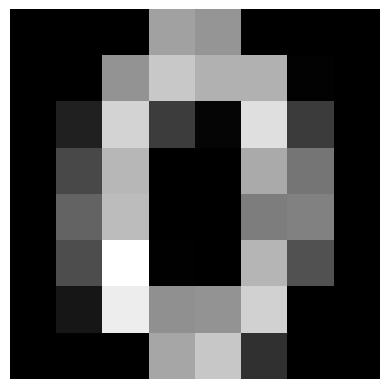

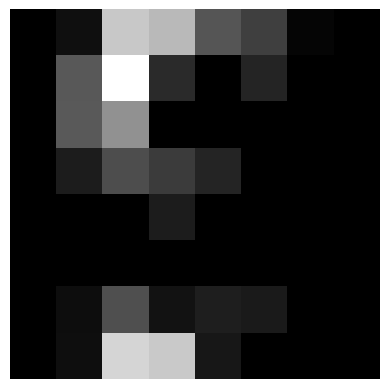

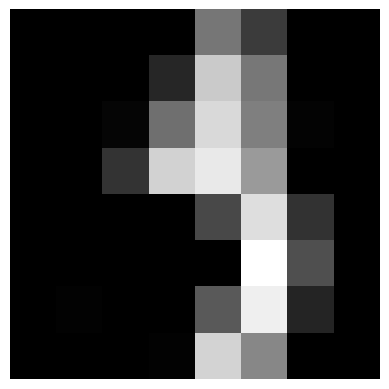

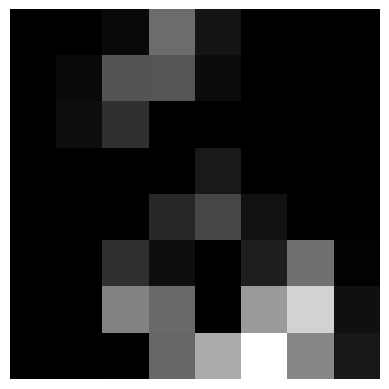

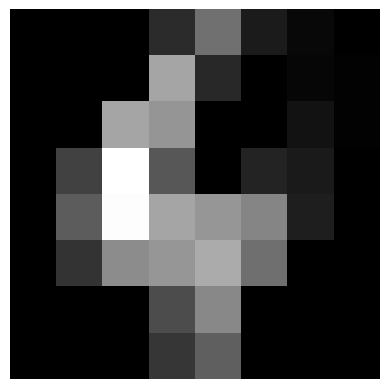

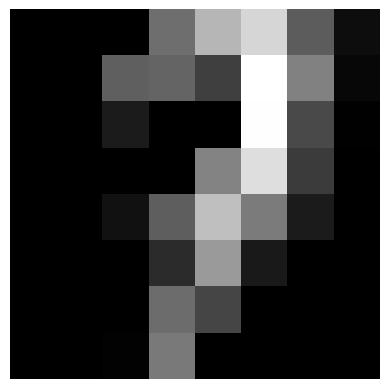

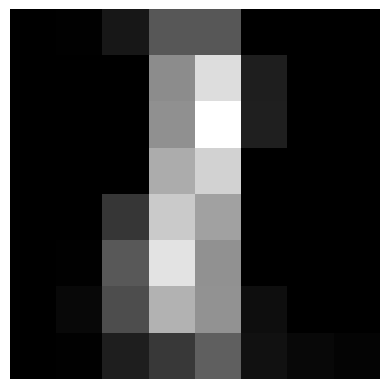

In [3]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=7, random_state=0)
features_nmf = nmf.fit_transform(samples)

for comp in nmf.components_:
    show_as_image(comp)


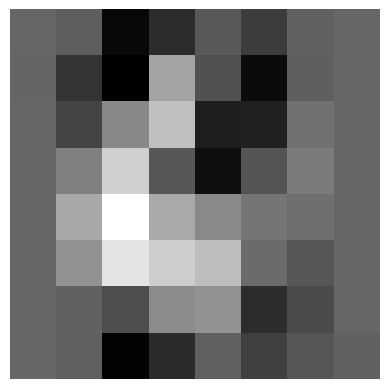

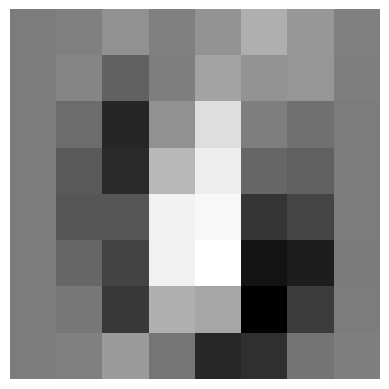

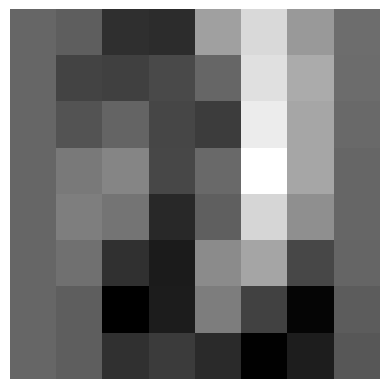

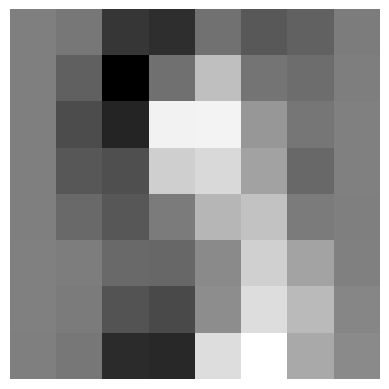

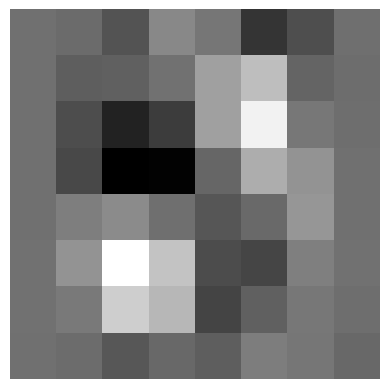

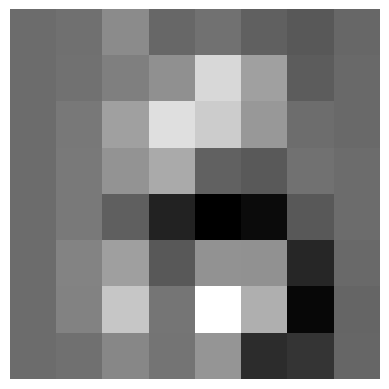

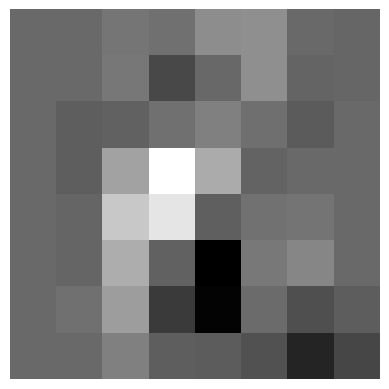

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)
features_pca = pca.fit_transform(samples)

for comp in pca.components_:
    show_as_image(comp)


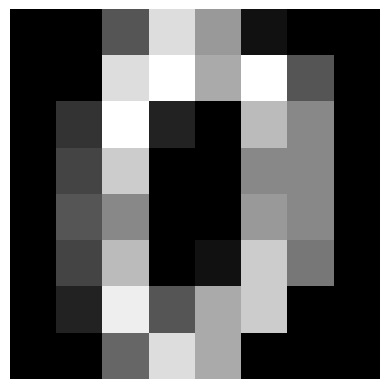

Label: 0


In [5]:
# Show an actual digit from the dataset
show_as_image(samples[0])

# (optional) see which digit it is
print("Label:", digits.target[0])


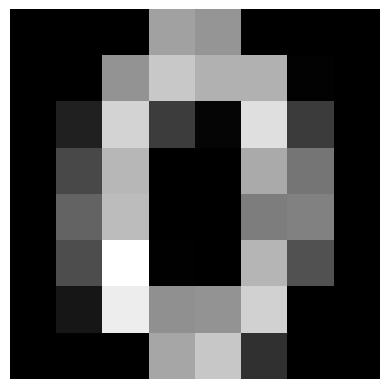

In [6]:
from sklearn.decomposition import NMF

model = NMF(n_components=7, random_state=0)
features = model.fit_transform(samples)

# Show one learned part (component 0)
show_as_image(model.components_[0])


In [7]:
from sklearn.datasets import load_digits
digits = load_digits()
samples = digits.data

from sklearn.decomposition import PCA
model = PCA(n_components=7)
features = model.fit_transform(samples)

def show_as_image(x, shape=(8, 8), cmap="gray"):
    import matplotlib.pyplot as plt
    plt.imshow(x.reshape(shape), cmap=cmap)
    plt.axis("off")
    plt.show()


Original 0 from dataset (index: 0 )


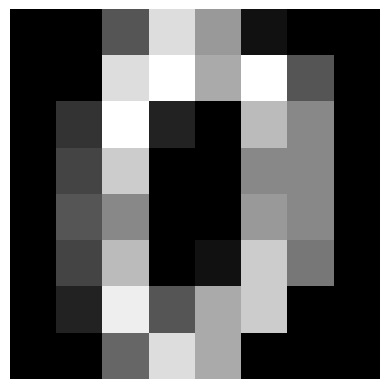

Same 0 reconstructed from PCA components:


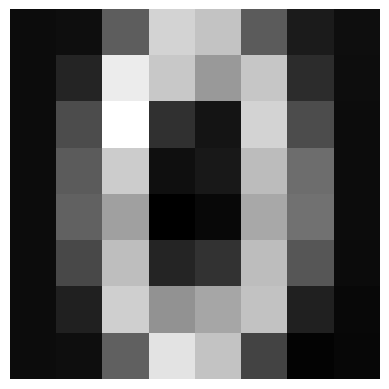

In [8]:
import numpy as np

# 1) Find one digit that is actually a 0 in the dataset
zero_index = np.where(digits.target == 0)[0][0]

# 2) Show the original 0
print("Original 0 from dataset (index:", zero_index, ")")
show_as_image(samples[zero_index])

# 3) Project this 0 into PCA space
zero_sample = samples[zero_index:zero_index+1]   # keep 2D shape (1, 64)
zero_pca = model.transform(zero_sample)

# 4) Reconstruct it back from PCA components
zero_recon = model.inverse_transform(zero_pca)

print("Same 0 reconstructed from PCA components:")
show_as_image(zero_recon[0])
